In [1]:
import ast
import json
import pandas as pd
import wandb

api = wandb.Api(timeout=90)
project = "laz4rz/star_graph_gidd_lr_sweep_multirun_slurm_d3p3n50"

def cfg_from_api(run_stub):
    # force full run object (list objects can be partial)
    run = api.run("/".join(run_stub.path))

    # 1) direct config if present
    direct = dict(run.config or {})
    if direct:
        return direct

    # 2) parse json_config from API
    raw = json.loads(run.json_config or "{}")
    if not raw:
        return {}

    # your runs often store full cfg under key "config"
    node = raw.get("config")
    if isinstance(node, dict) and "value" in node:
        v = node["value"]
        if isinstance(v, dict):
            return v
        if isinstance(v, str):
            try:
                return json.loads(v)          # if JSON string
            except Exception:
                try:
                    return ast.literal_eval(v)  # if python-literal string
                except Exception:
                    return {"_raw_config": v}

    # fallback: standard wandb key->{"value":...} format
    out = {}
    for k, node in raw.items():
        if k.startswith("_"):
            continue
        if isinstance(node, dict) and "value" in node:
            out[k] = node["value"]
    return out

# run_stubs = list(api.runs(project))
# df = pd.DataFrame(
#     [{"run_id": r.id, "name": r.name, "cfg": cfg_from_api(r)} for r in run_stubs]
# )

# print("rows:", len(df), "non-empty cfg:", sum(bool(x) for x in df.cfg))
# df.head()


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /users/mboronski/.netrc.


In [14]:
runs = api.runs("laz4rz/star_graph_gidd_lr_sweep_multirun_slurm_d3p3n50", lazy=False)
runs[0].__dict__

{'_attrs': {'projectId': '43879754',
  'id': 'UnVuOnYxOjI1M3B1bzV0OnN0YXJfZ3JhcGhfZ2lkZF9scl9zd2VlcF9tdWx0aXJ1bl9zbHVybV9kM3AzbjUwOmxhejRyeg==',
  'tags': ['gidd', 'star_graph'],
  'name': '253puo5t',
  'displayName': 'd3p3n50-s1-lr3.1622776601683795e-05-pu0',
  'sweepName': None,
  'state': 'finished',
  'config': {'algo': {'T': 0,
    'name': 'gidd',
    't_eps': 0.0001,
    'sampler': {'_target_': 'discrete_diffusion.sampling.gidd.GIDDSampler'},
    '_target_': 'discrete_diffusion.algorithms.gidd.GIDD',
    'backbone': 'dit',
    'loss_type': 'gidd_constant_pi',
    'p_uniform': 0,
    'loss_weighting': 'clip',
    'max_loss_weight': 1,
    'min_loss_weight': 0,
    'causal_attention': False,
    'parameterization': 'subs',
    'time_conditioning': True,
    'low_discrepancy_sampling': True},
   'data': {'wrap': False,
    'train': 'star_graph',
    'valid': 'star_graph',
    'chunking': 'none',
    'cache_dir': '/tmp/discrete_diffusion/pooled-20260317_123316/pool-0006',
    'stream

In [ ]:
d3p3n50 = "laz4rz/star_graph_gidd_lr_sweep_multirun_slurm_d3p3n50"


runs = api.runs("laz4rz/star_graph_gidd_lr_sweep_multirun_slurm_d3p3n50", filters={"config.algo.p_uniform": 1})

for run in runs:
    print(run.summary)
    break



{'_runtime': 248.372137825, '_step': 649, '_timestamp': 1773749629.4778016, '_wandb': {'runtime': 249}, 'epoch': 10, 'train/bpd': 0.3946451865460369, 'train/denoise_acc_sample': 0.1284871769772905, 'train/denoise_acc_token': 0.6175248765249954, 'train/elbo': 1.3300392627716064, 'train/is_loss': 0.15592485666275024, 'train/kl_loss': 0.3417060673236847, 'train/nll': 0.27354719837593916, 'train/ppl': 1.314619405648726, 'trainer/global_step': 7820, 'trainer/loss': 0.25440752506256104, 'trainer/lr': 3.162277660168379e-06, 'val/bpd': 0.42851848698735495, 'val/denoise_acc_sample': 0.11675, 'val/denoise_acc_token': 0.5997814428561502, 'val/gen_acc_sample': 0, 'val/gen_acc_token': 0.2234540527223454, 'val/nll': 0.2970263810730987, 'val/ppl': 1.345850803968211}


In [13]:
import pandas as pd

def wandb_pu_lr_table(api, project):
    blocks = {}

    for pu in (0, 1):
        runs = list(api.runs(project, filters={"config.algo.p_uniform": pu}, lazy=False))
        if not runs:
            raise RuntimeError(f"No runs found for p_uniform={pu}")

        rows = []
        for run in runs:
            s = dict(run.summary)
            lr = s.get("trainer/lr")
            if lr is None:
                raise KeyError(f"Run {run.id} has no summary['trainer/lr']")

            metrics = {
                k: float(v)
                for k, v in s.items()
                if isinstance(v, (int, float))
                and not isinstance(v, bool)
                and not k.startswith("_")
                and k != "trainer/lr"
            }
            if not metrics:
                raise RuntimeError(f"Run {run.id} has no numeric summary metrics")

            metrics["lr"] = float(lr)
            rows.append(metrics)

        # multiple seeds per lr -> average; change 'mean' to 'first' if you want one run only
        block = pd.DataFrame(rows).groupby("lr", as_index=True).mean(numeric_only=True).sort_index()
        if block.empty:
            raise RuntimeError(f"Empty block for p_uniform={pu}")

        blocks[pu] = block

    out = pd.concat(blocks, axis=1).sort_index(axis=1)
    out.columns.names = ["p_uniform", "metric"]
    return out.sort_index()


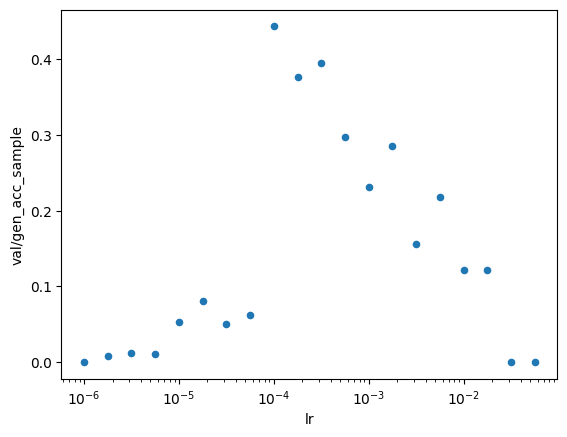

In [ ]:
df = wandb_pu_lr_table(api, "laz4rz/star_graph_gidd_lr_sweep_multirun_slurm_d3p3n50")
ax = df.xs(1, axis=1, level=0).reset_index().plot.scatter(x="lr", y="val/gen_acc_sample")
ax.set_xscale("log")

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def plot_all_configs(api, projects, metric="val/gen_acc_sample"):
    """
    projects: {"d3p3n50": "entity/project", ...}
    Requires wandb_pu_lr_table(api, project) -> DataFrame:
      index = lr
      columns = MultiIndex (p_uniform, metric)
    """

    def lr_key(v):
        return f"{float(v):.12g}"

    dfs = {}
    lr_map = {}  # stable unique global LR set
    y_left_top = -np.inf

    # Load + validate + collect global unique LRs
    for label, project in projects.items():
        df = wandb_pu_lr_table(api, project)
        if df.empty:
            raise RuntimeError(f"{label}: empty dataframe")

        for p in (0, 1):
            col = (p, metric)
            if col not in df.columns:
                raise KeyError(f"{label}: missing column {col}")
            vals = df[col].dropna().to_numpy(dtype=float)
            if vals.size == 0:
                raise RuntimeError(f"{label}: no values for {col}")
            y_left_top = max(y_left_top, float(np.nanmax(vals)))

        for lr in np.asarray(df.index, dtype=float):
            lr_map.setdefault(lr_key(lr), float(lr))

        dfs[label] = df

    if not lr_map:
        raise RuntimeError("No LR values found")

    lr_items = sorted(lr_map.items(), key=lambda kv: kv[1])
    lr_keys = [k for k, _ in lr_items]
    lr_vals = np.array([v for _, v in lr_items], dtype=float)  # TRUE x-axis values

    y_left_top = 1.0 if y_left_top <= 1.000001 else y_left_top * 1.02

    n = len(dfs)
    fig, axes = plt.subplots(
        n, 2, figsize=(14, 3.2 * n), sharex=True, sharey=True, constrained_layout=True
    )
    if n == 1:
        axes = np.array([axes])

    for r, (label, df) in enumerate(dfs.items()):
        for c, p in enumerate((0, 1)):
            ax = axes[r, c]
            s = df[(p, metric)]

            lr_to_y = {
                lr_key(lr): float(y)
                for lr, y in s.items()
                if np.isfinite(y)
            }
            y_grid = np.array([lr_to_y.get(k, np.nan) for k in lr_keys], dtype=float)

            m = np.isfinite(y_grid)
            x_plot = lr_vals[m]          # <- actual lr values
            y_plot = y_grid[m]

            # Left axis
            ax.scatter(x_plot, y_plot, s=24, alpha=0.85, color="tab:blue")
            ax.plot(x_plot, y_plot, lw=1.1, alpha=0.6, color="tab:blue")
            ax.set_xscale("log")
            ax.set_ylim(0.0, y_left_top)
            ax.grid(alpha=0.25)

            if r == 0:
                ax.set_title(f"p_uniform={p}")
            if c == 0:
                ax.set_ylabel(f"{label}\n{metric}")

            # Right red axis (local magnified scale, labels in original metric units)
            ax2 = ax.twinx()
            local_max = float(np.nanmax(y_plot)) if y_plot.size else 0.0
            local_top = 1.0 if local_max >= 0.999999 else max(local_max * 1.05, 1e-12)
            scale = y_left_top / local_top
            ax2.plot(x_plot, y_plot * scale, color="red", lw=2.0, alpha=0.9)
            ax2.set_ylim(0.0, y_left_top)
            ax2.tick_params(axis="y", colors="red")
            ax2.spines["right"].set_color("red")
            ax2.yaxis.set_major_formatter(
                mticker.FuncFormatter(lambda v, _pos, s=scale: f"{v/s:.3g}")
            )
            if c == 1:
                ax2.set_ylabel(f"{metric} (red local scale)", color="red")

    # Use real LR ticks (subset if many)
    if len(lr_vals) <= 15:
        tick_vals = lr_vals
    else:
        idx = np.unique(np.linspace(0, len(lr_vals) - 1, 12).round().astype(int))
        tick_vals = lr_vals[idx]

    for ax in axes.ravel():
        ax.set_xticks(tick_vals)

    for ax in axes[-1, :]:
        ax.set_xticklabels([f"{v:.2e}" for v in tick_vals], rotation=45, ha="right")
        ax.set_xlabel("lr")

    fig.suptitle(f"{metric} across configs and p_uniform (x axis = true lr)", y=1.02)
    return fig, axes, dfs, lr_vals


In [38]:
PROJECTS = {
    "d3p3n50": "laz4rz/star_graph_gidd_lr_sweep_multirun_slurm_d3p3n50",
    "d5p3n50": "laz4rz/star_graph_gidd_lr_sweep_multirun_slurm_d5p3n50",
    "d2p5n50": "laz4rz/star_graph_gidd_lr_sweep_multirun_slurm_d2p5n50",
    "d2p2n50": "laz4rz/star_graph_gidd_lr_sweep_multirun_slurm_d2p2n50",
}

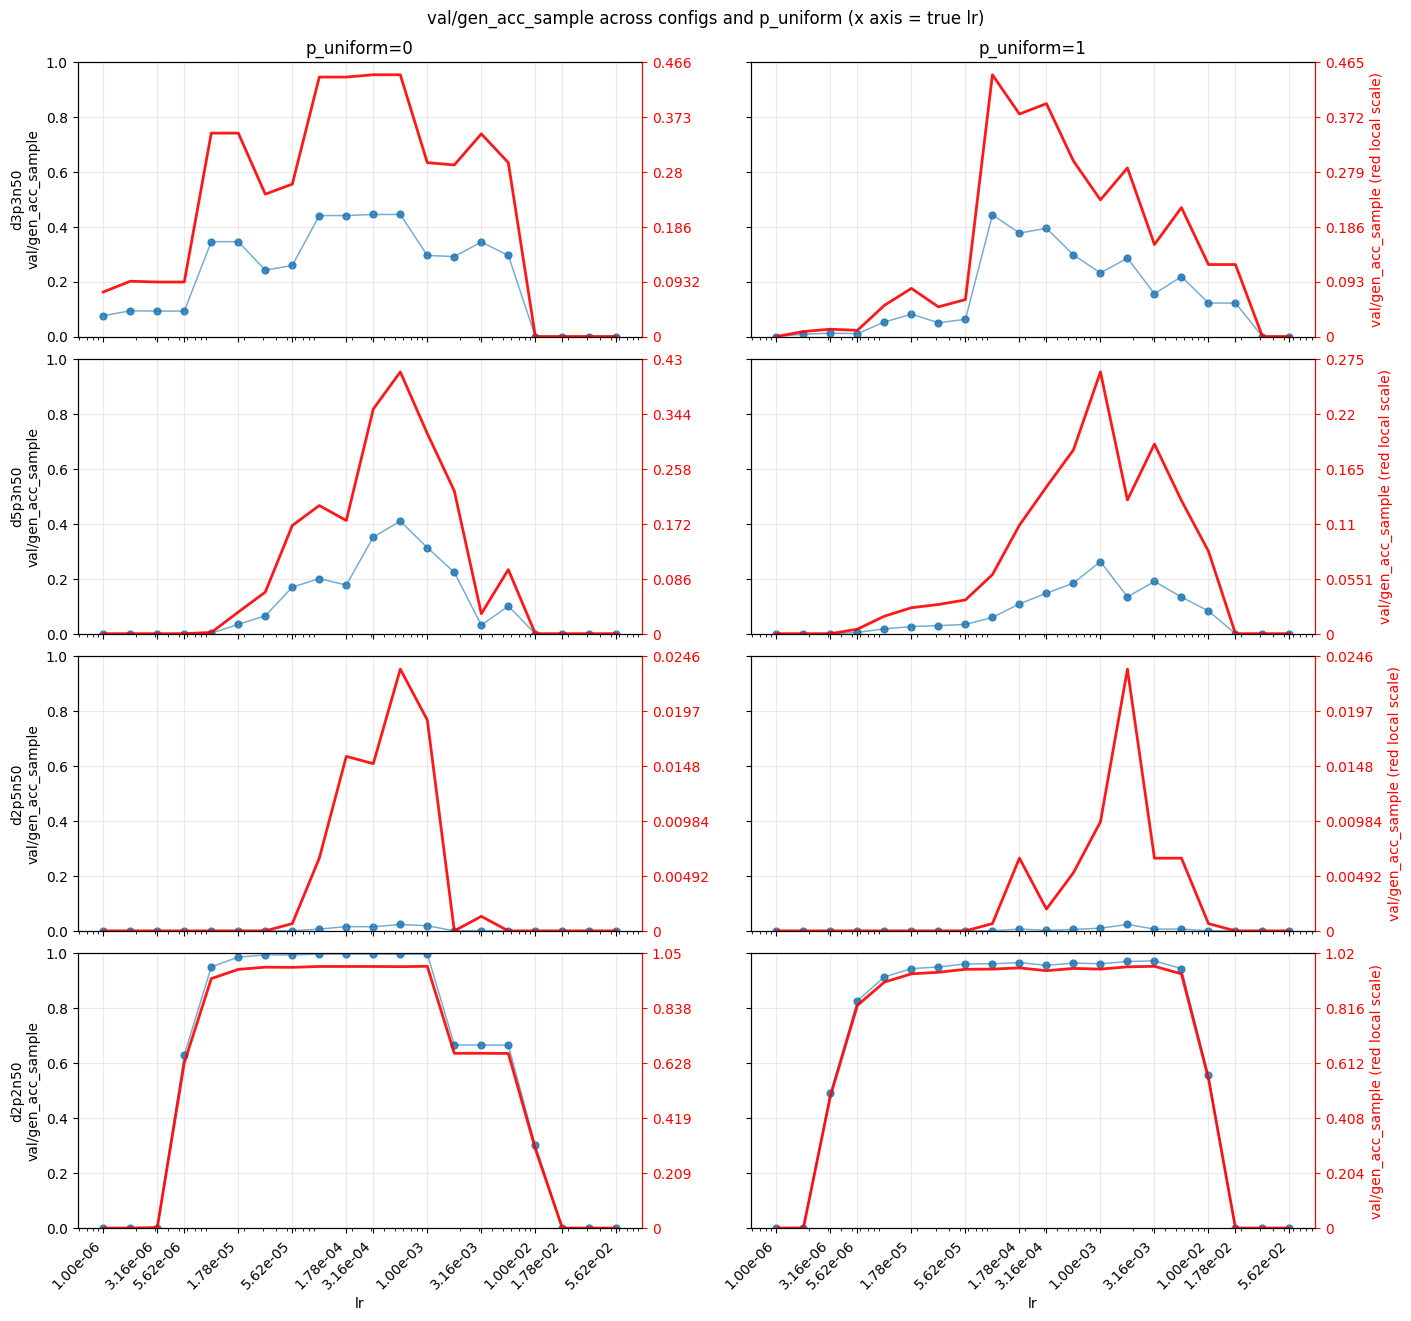

In [42]:
fig, axes, dfs, lr = plot_all_configs(api, PROJECTS, metric="val/gen_acc_sample")